In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
from matplotlib import pyplot

# 1. Veri Setini Yükleme
df = pd.read_csv("data/lip_0_x.csv")

# 2. Eksik Değer Kontrolü
print("Missing values:")
print(df.isnull().sum())
print("-----------------------------")
# 3. İlk 5 Satırı Görüntüle
print(df.head())

Missing values:
time    0
0_x     0
dtype: int64
-----------------------------
   time  0_x
0  0.00  637
1  0.04  638
2  0.08  638
3  0.12  638
4  0.16  638


<Axes: >

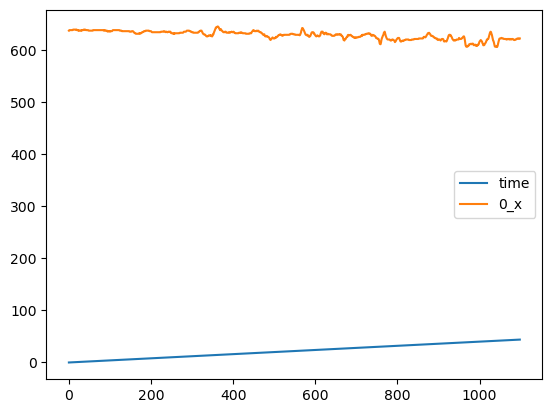

In [21]:
df.plot()

predicted=631.936355, expected=631.000000
predicted=630.487491, expected=630.000000
predicted=629.265233, expected=628.000000
predicted=627.250953, expected=627.000000
predicted=626.317329, expected=627.000000
predicted=626.835415, expected=627.000000
predicted=627.282924, expected=627.000000
predicted=627.199861, expected=626.000000
predicted=625.770878, expected=626.000000
predicted=625.824676, expected=625.000000
predicted=624.734919, expected=624.000000
predicted=623.677498, expected=624.000000
predicted=623.801493, expected=623.000000
predicted=622.897554, expected=623.000000
predicted=623.004073, expected=622.000000
predicted=621.778257, expected=622.000000
predicted=622.015610, expected=622.000000
predicted=622.088170, expected=622.000000
predicted=622.275304, expected=620.000000
predicted=619.548900, expected=620.000000
predicted=619.648248, expected=619.000000
predicted=618.770521, expected=620.000000
predicted=620.469915, expected=620.000000
predicted=620.385732, expected=620

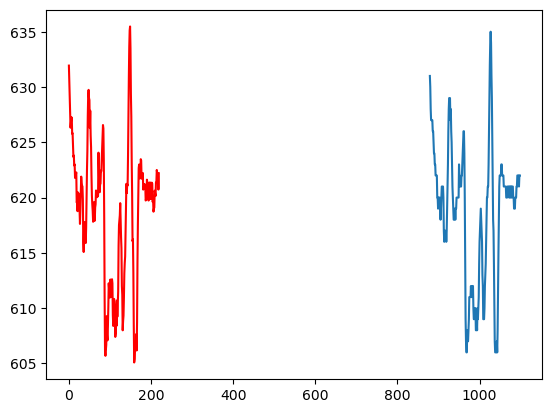

In [47]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(5,0,0)) # ARIMA modeli oluşturuluyor (son 5 değer)
	model_fit = model.fit() # Model eğitiliyor
	output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
	yhat = output[0] # Tahmin sonucu
	predictions.append(yhat) # Tahmini kaydet
	obs = test.iloc[t] # Gerçek değer
	history.append(obs) # Modeli güncelle (bir sonraki tahmin için)
	print('predicted=%f, expected=%f' % (yhat, obs))  # Ekrana yazdır
# evaluate forecasts
mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - predictions) / test)) * 100
print('Test MAE: %.3f' % mae)
print('Test MSE: %.3f' % mse)
print('Test RMSE: %.3f' % rmse)
print('Test MAPE: %.3f' % mape)
# plot forecasts against actual outcomes
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

predicted=631.764852, expected=631.000000
predicted=630.439768, expected=630.000000
predicted=629.198339, expected=628.000000
predicted=627.063574, expected=627.000000
predicted=626.315365, expected=627.000000
predicted=626.836316, expected=627.000000
predicted=627.196672, expected=627.000000
predicted=627.258737, expected=626.000000
predicted=625.830407, expected=626.000000
predicted=625.862803, expected=625.000000
predicted=624.886115, expected=624.000000
predicted=623.805905, expected=624.000000
predicted=623.847176, expected=623.000000
predicted=622.862898, expected=623.000000
predicted=623.004653, expected=622.000000
predicted=621.836434, expected=622.000000
predicted=621.987124, expected=622.000000
predicted=622.146757, expected=622.000000
predicted=622.331322, expected=620.000000
predicted=619.591337, expected=620.000000
predicted=619.658613, expected=619.000000
predicted=618.766857, expected=620.000000
predicted=620.503601, expected=620.000000
predicted=620.454799, expected=620

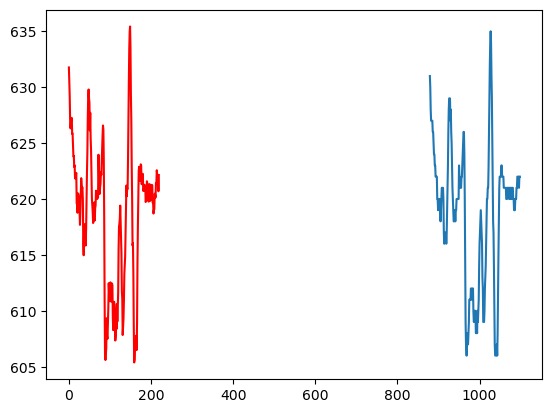

In [49]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(10,0,0)) # ARIMA modeli oluşturuluyor (son 10 değer)
	model_fit = model.fit() # Model eğitiliyor
	output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
	yhat = output[0] # Tahmin sonucu
	predictions.append(yhat) # Tahmini kaydet
	obs = test.iloc[t] # Gerçek değer
	history.append(obs) # Modeli güncelle (bir sonraki tahmin için)
	print('predicted=%f, expected=%f' % (yhat, obs))  # Ekrana yazdır
# evaluate forecasts
mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - predictions) / test)) * 100
print('Test MAE: %.3f' % mae)
print('Test MSE: %.3f' % mse)
print('Test RMSE: %.3f' % rmse)
print('Test MAPE: %.3f' % mape)
# plot forecasts against actual outcomes
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

predicted=631.741961, expected=631.000000
predicted=630.402581, expected=630.000000
predicted=629.221135, expected=628.000000
predicted=627.076216, expected=627.000000
predicted=626.266194, expected=627.000000
predicted=626.721735, expected=627.000000
predicted=627.120742, expected=627.000000
predicted=627.238066, expected=626.000000
predicted=625.718655, expected=626.000000
predicted=625.805427, expected=625.000000
predicted=624.913281, expected=624.000000
predicted=623.779045, expected=624.000000
predicted=623.866529, expected=623.000000
predicted=622.950286, expected=623.000000
predicted=623.058668, expected=622.000000
predicted=621.924140, expected=622.000000
predicted=622.097607, expected=622.000000
predicted=622.198244, expected=622.000000
predicted=622.324058, expected=620.000000
predicted=619.595345, expected=620.000000
predicted=619.700147, expected=619.000000
predicted=618.785973, expected=620.000000
predicted=620.522971, expected=620.000000
predicted=620.513766, expected=620

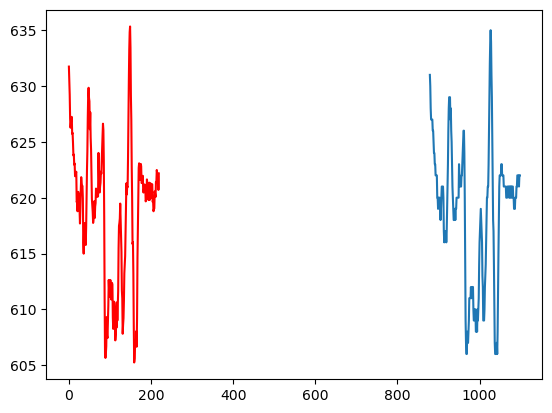

In [51]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(15,0,0)) # ARIMA modeli oluşturuluyor (son 15 değer)
	model_fit = model.fit() # Model eğitiliyor
	output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
	yhat = output[0] # Tahmin sonucu
	predictions.append(yhat) # Tahmini kaydet
	obs = test.iloc[t] # Gerçek değer
	history.append(obs) # Modeli güncelle (bir sonraki tahmin için)
	print('predicted=%f, expected=%f' % (yhat, obs))  # Ekrana yazdır
# evaluate forecasts
mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - predictions) / test)) * 100
print('Test MAE: %.3f' % mae)
print('Test MSE: %.3f' % mse)
print('Test RMSE: %.3f' % rmse)
print('Test MAPE: %.3f' % mape)
# plot forecasts against actual outcomes
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

In [ ]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(20,0,0)) # ARIMA modeli oluşturuluyor (son 20 değer)
	model_fit = model.fit() # Model eğitiliyor
	output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
	yhat = output[0] # Tahmin sonucu
	predictions.append(yhat) # Tahmini kaydet
	obs = test.iloc[t] # Gerçek değer
	history.append(obs) # Modeli güncelle (bir sonraki tahmin için)
	print('predicted=%f, expected=%f' % (yhat, obs))  # Ekrana yazdır
# evaluate forecasts
mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - predictions) / test)) * 100
print('Test MAE: %.3f' % mae)
print('Test MSE: %.3f' % mse)
print('Test RMSE: %.3f' % rmse)
print('Test MAPE: %.3f' % mape)
# plot forecasts against actual outcomes
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()

predicted=631.650774, expected=631.000000
predicted=630.264948, expected=630.000000
predicted=629.065726, expected=628.000000
predicted=627.044062, expected=627.000000
predicted=626.364965, expected=627.000000
predicted=626.755972, expected=627.000000
predicted=627.169512, expected=627.000000
predicted=627.140406, expected=626.000000
predicted=625.597288, expected=626.000000
predicted=625.728207, expected=625.000000
predicted=624.805091, expected=624.000000
predicted=623.740515, expected=624.000000
predicted=623.811245, expected=623.000000
predicted=622.925490, expected=623.000000
predicted=623.101865, expected=622.000000
predicted=621.896286, expected=622.000000
predicted=622.153572, expected=622.000000
predicted=622.355031, expected=622.000000
predicted=622.472609, expected=620.000000
predicted=619.746537, expected=620.000000
predicted=619.753737, expected=619.000000
predicted=618.722695, expected=620.000000
predicted=620.512400, expected=620.000000
predicted=620.504685, expected=620

C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: 

predicted=10.993744, expected=622.000000
Test MAE: 607.729
Test MSE: 369373.909
Test RMSE: 607.761
Test MAPE: 98.223


C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


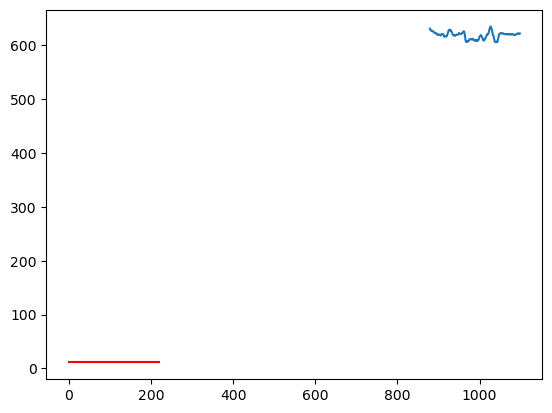

In [85]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()


# walk-forward validation
for t in range(len(test)):
    #input_data = history[-20:]
    input_data = [5,6,7,8,9,10]
    model = ARIMA(input_data, order=(5,0,0)) # ARIMA modeli oluşturuluyor (son 1 değer)
    model_fit = model.fit() # Model eğitiliyor
    output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
    yhat = output[0] # Tahmin sonucu
    predictions.append(yhat) # Tahmini kaydet
    obs = test.iloc[t] # Gerçek değer
    history.append(obs) # Modeli güncelle (bir sonraki tahmin için)
print('predicted=%f, expected=%f' % (yhat, obs))  # Ekrana yazdır
# evaluate forecasts
mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test - predictions) / test)) * 100
print('Test MAE: %.3f' % mae)
print('Test MSE: %.3f' % mse)
print('Test RMSE: %.3f' % rmse)
print('Test MAPE: %.3f' % mape)
# plot forecasts against actual outcomes
pyplot.plot(test)
pyplot.plot(predictions, color='red')
pyplot.show()